# Imports

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model


from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, LSTM, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import ReduceLROnPlateau


from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Flatten

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay


#Criando Features e Tratando os dados

In [40]:
# Função para criar novas features: desvio padrão, variancia e tendência de alta ou baixa.
def add_features(df):

    df['std_15_days'] = df[[f'Past_{i}_Days_Close' for i in range(1, 16)]].std(axis=1)
    df['variance_15_days'] = df[[f'Past_{i}_Days_Close' for i in range(1, 16)]].var(axis=1)


    #Tendências: Dias consecutivos de alta e baixa
    df['up_streak'] = df[[f'Past_{i}_Days_Close' for i in range(1, 16)]].apply(
        lambda row: sum(1 for i in range(14) if row[i] > row[i + 1]), axis=1
    )
    df['down_streak'] = df[[f'Past_{i}_Days_Close' for i in range(1, 16)]].apply(
        lambda row: sum(1 for i in range(14) if row[i] < row[i + 1]), axis=1
    )

    return df

# Função para carregar os arquivos e remover as colunas 'Unnamed: 0', 'Close', 'Smoothed_Close'
def load_and_preprocess_data(file_path):


    df = pd.read_csv(file_path)

    colunas_para_remover = ['Unnamed: 0', 'Close', 'Smoothed_Close']
    df = df.drop(columns=colunas_para_remover)

    # Função de adicionar novas features
    df = add_features(df)

    # Separar features e label
    X = df.drop(columns=['Date', 'Label']).values  # Remover colunas irrelevantes e label
    y = df['Label'].values  # A coluna "Label"

    # Normalização
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)

    # Ajustar dimensões para redes neurais.
    X = X.reshape(X.shape[0], X.shape[1], 1)

    # Converter os labels para categórico.
    y = to_categorical((y + 1) // 2)

    return X, y

# Carregar dados de treino e teste
X_train, y_train = load_and_preprocess_data('treino.csv')
X_test, y_test = load_and_preprocess_data('teste.csv')


<ipython-input-40-35ac6086fd6a>:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda row: sum(1 for i in range(14) if row[i] > row[i + 1]), axis=1
<ipython-input-40-35ac6086fd6a>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda row: sum(1 for i in range(14) if row[i] < row[i + 1]), axis=1
<ipython-input-40-35ac6086fd6a>:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda row: sum(1 for i in range(14) if row[i] > row

# Modelo CNN

In [41]:

# Construção do modelo CNN
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),  # Normaliza as ativações da camada
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    BatchNormalization(),

    MaxPooling1D(pool_size=1),
    Dropout(0.4),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # 2 classes: comprar/vender
])

# Compilação do modelo
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callback.
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

cnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=64, callbacks=[reduce_lr])


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5914 - loss: 0.9869 - val_accuracy: 0.4996 - val_loss: 0.6987 - learning_rate: 0.0010
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6678 - loss: 0.6636 - val_accuracy: 0.4996 - val_loss: 0.7862 - learning_rate: 0.0010
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6888 - loss: 0.5974 - val_accuracy: 0.4996 - val_loss: 1.0319 - learning_rate: 0.0010
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7365 - loss: 0.5249 - val_accuracy: 0.4996 - val_loss: 1.2181 - learning_rate: 0.0010
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7399 - loss: 0.5251 - val_accuracy: 0.5312 - val_loss: 0.8121 - learning_rate: 0.0010
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7385 - loss: 0.4987 - val_accuracy: 0.6750 - val_loss: 0.6618 - learning_rate: 0.0010
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7687 - loss: 0.4706 - val_accuracy: 0.512

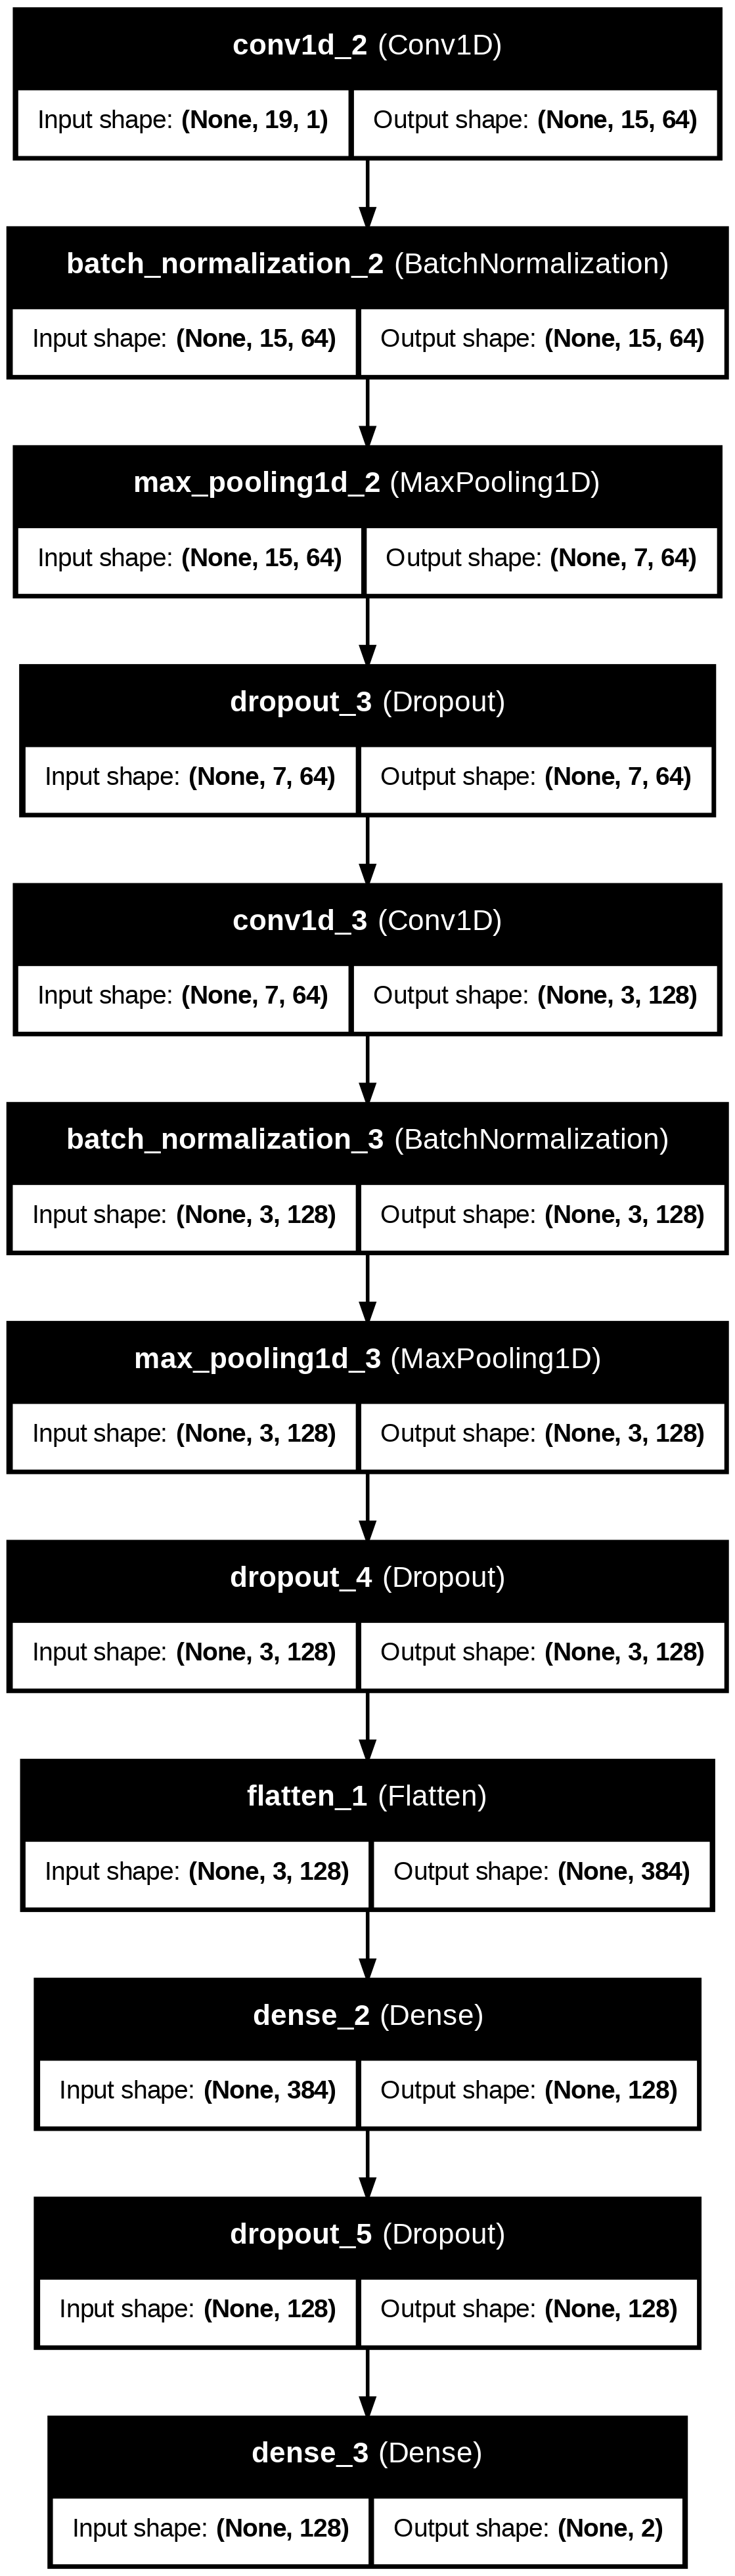

In [42]:
plot_model(cnn_model,show_shapes=True, show_layer_names=True)

In [43]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 15, 64)              │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 15, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 3, 128)              │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 3, 128)              │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 274,568 (1.05 MB)

 Trainable params: 91,394 (357.01 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 182,790 (714.03 KB)

# Acurácia no Conjunto de Teste

In [44]:
# Avaliação no conjunto de teste
cnn_predictions = cnn_model.predict(X_test)
cnn_predicted_class = np.argmax(cnn_predictions, axis=1)
cnn_true_class = np.argmax(y_test, axis=1)

# Cálculos de desempenho
cnn_accuracy = accuracy_score(cnn_true_class, cnn_predicted_class)
cnn_confusion_matrix = confusion_matrix(cnn_true_class, cnn_predicted_class)
cnn_precision = precision_score(cnn_true_class, cnn_predicted_class)
cnn_recall = recall_score(cnn_true_class, cnn_predicted_class)

print(f"CNN Accuracy: {cnn_accuracy:.2%}")
print(f"CNN Precision: {cnn_precision:.2f}")
print(f"CNN Recall: {cnn_recall:.2f}")
print("CNN Confusion Matrix:\n", cnn_confusion_matrix)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
CNN Accuracy: 86.03%
CNN Precision: 0.85
CNN Recall: 0.87
CNN Confusion Matrix:
 [[512  89]
 [ 79 523]]


#Backseat

**Parâmetros**


predicoes: de compra e venda.


1: Sinal para comprar.


0: Sinal para vender.


precos: Array com os preços do ativo em cada instante de tempo.


saldo_inicial: O saldo inicial disponível para investimento de 10.000.


balanco: Representa o saldo em dinheiro disponível.

posicao: Quantidade de ativos comprados atualmente.

preco_compra: Preço do ativo no momento em que foi comprado.

curva: Lista que acompanha o valor total da conta (soma de saldo e valor dos ativos) ao longo do tempo.



**Explicação**

Para cada instante i, o preço e a previsão (predicao[i]) são analisados.
Compra (predicao[i] == 1):

Compra o ativo caso não haja posição aberta (posicao == 0).
Calcula a quantidade de ativos que pode ser comprada: balanco / preco_compra.
Zera o saldo disponível (balanco).
Venda (predicao[i] == 0):

Vende o ativo caso haja posição aberta (posicao > 0).
Calcula o saldo final após vender todos os ativos: posicao * preco_venda.
Zera a posição.
Atualização do valor total:

Após cada iteração, o valor total da conta (dinheiro + valor da posição aberta) é calculado e armazenado em curva.
Retorno Financeiro:

Subtrai o saldo inicial do saldo final para calcular o lucro/prejuízo.

In [45]:
#Função de backseat para simular o desempenho de uma estratégia de trading.


def backtest(predicoes, precos, saldo_inicial=10000, return_equity_curve=False):

    balanco = saldo_inicial
    posicao = 0
    preco_compra = 0
    curva = []

    for i in range(len(predicoes)):
        if predicoes[i] == 1 and posicao == 0:  # Comprar
            preco_compra = precos[i]
            posicao = balanco / preco_compra
        elif predicoes[i] == 0 and posicao > 0:  # Vender
            preco_venda = precos[i]
            balanco = posicao * preco_venda
            posicao = 0
        curva.append(balanco + posicao * precos[i])

    if return_equity_curve:
        return curva  # Retorna a curva de equity
    else:
        return curva[-1] - saldo_inicial  # Retorna o retorno financeiro

# Carregando df novamente.
df = pd.read_csv('treino.csv')

# Obter preços do fundo de ações
precos = np.array(df['Past_1_Days_Close'].values)

# Realizar backtest para o modelo CNN
cnn_profit = backtest(cnn_predicted_class, precos)
print(f"CNN ganhos: {cnn_profit:.2f}")


CNN ganhos: 51963.08


#Gráficos e Análise

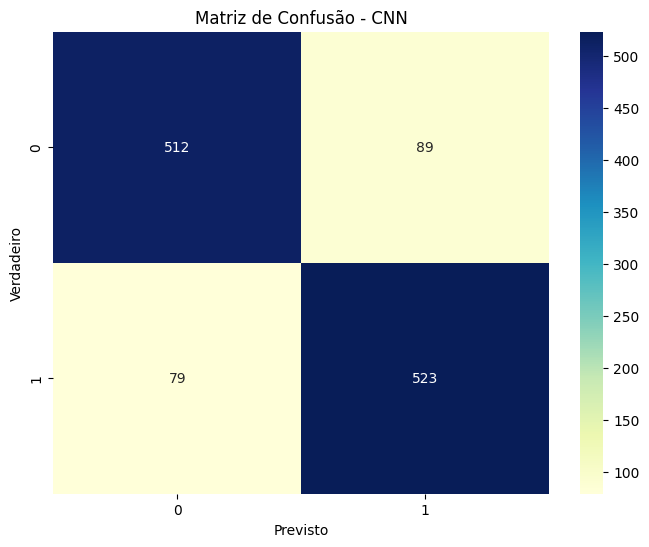

In [46]:
# Matriz de confusão para CNN
plt.figure(figsize=(8, 6))
sns.heatmap(cnn_confusion_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Matriz de Confusão - CNN')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()



Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8166 - loss: 0.3707 - val_accuracy: 0.8620 - val_loss: 0.3222 - learning_rate: 2.5000e-04
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8275 - loss: 0.3639 - val_accuracy: 0.8504 - val_loss: 0.3464 - learning_rate: 2.5000e-04
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8318 - loss: 0.3618 - val_accuracy: 0.8628 - val_loss: 0.3365 - learning_rate: 2.5000e-04
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8337 - loss: 0.3559 - val_accuracy: 0.8603 - val_loss: 0.3247 - learning_rate: 2.5000e-04
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8288 - loss: 0.3491 - val_accuracy: 0.8612 - val_loss: 0.3433 - learning_rate: 2.5000e-04
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8399 - loss: 0.3491 - val_accuracy: 0.8113 - val_loss: 0.4803 - learning_rate: 2.5000e-04
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8222 -

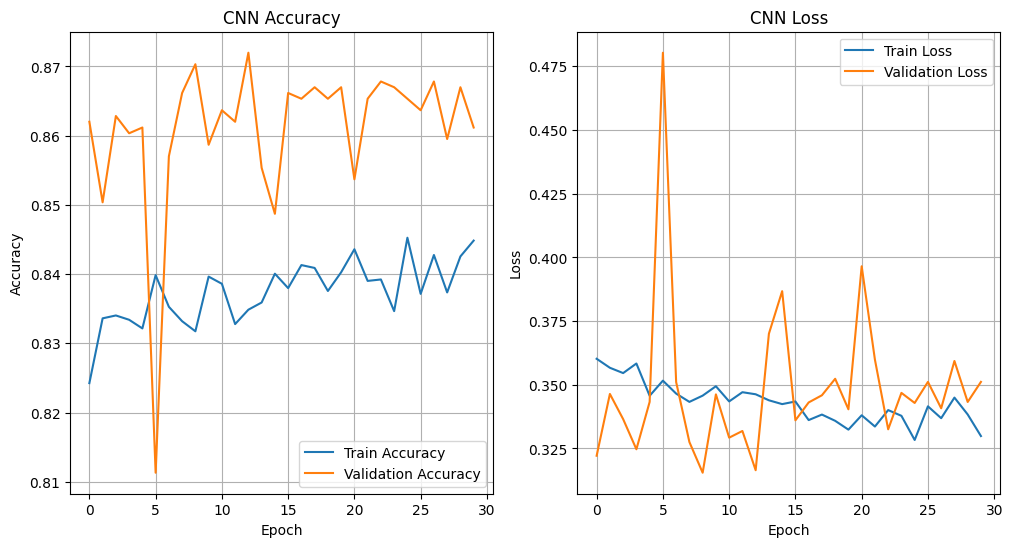

In [47]:
# Treinamento o modelo novamente e salvando o histórico em uma variável
history = cnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=64, callbacks=[reduce_lr])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Use 'accuracy' if available
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # Use 'val_accuracy' if available
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

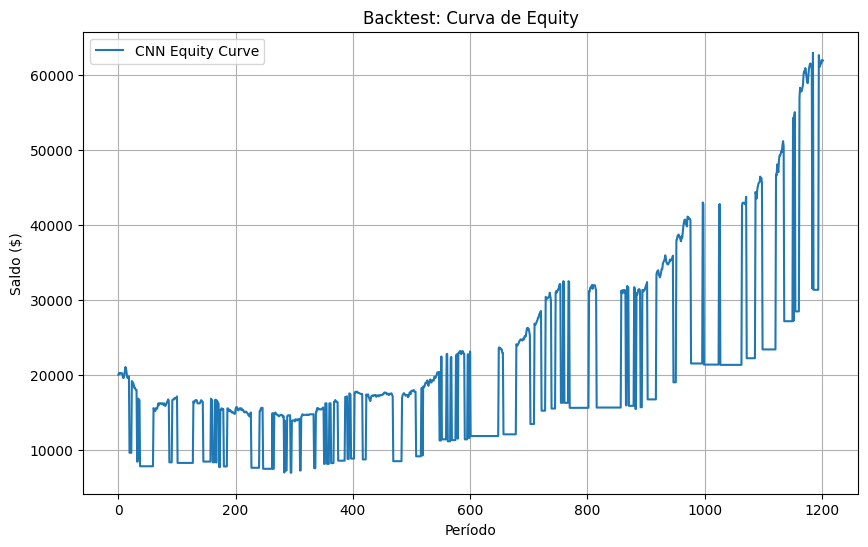

In [48]:
cnn_equity_curve = backtest(cnn_predicted_class, precos, return_equity_curve=True)

plt.figure(figsize=(10, 6))
plt.plot(cnn_equity_curve, label='CNN Equity Curve')
plt.title('Backtest: Curva de Equity')
plt.xlabel('Período')
plt.ylabel('Saldo ($)')
plt.legend()
plt.grid()
plt.show()


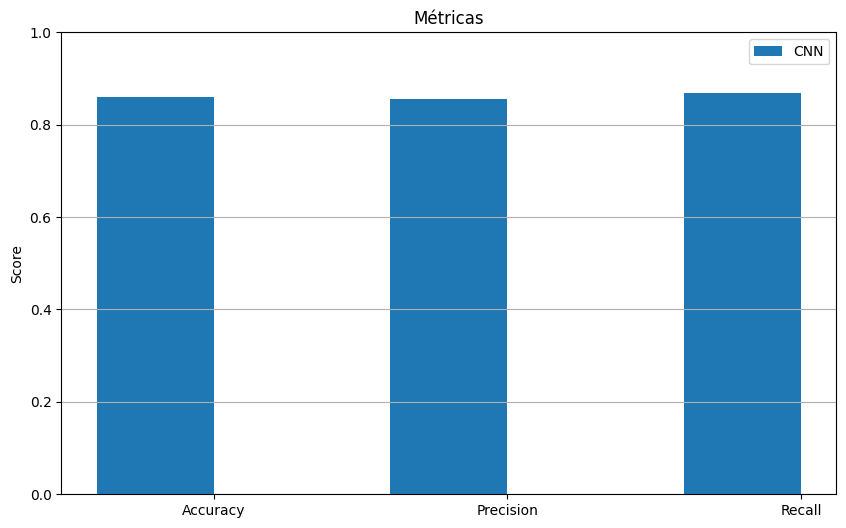

In [49]:
metrics = ['Accuracy', 'Precision', 'Recall']
cnn_scores = [cnn_accuracy, cnn_precision, cnn_recall]
x = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(x - 0.2, cnn_scores, width=0.4, label='CNN')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.title('Métricas')
plt.ylabel('Score')
plt.legend()
plt.grid(axis='y')
plt.show()